# Figure 3

Modeled saturation pressures and measured CO2 concentrations in melt inclusions from Fogo (purple downward triangles) and Fuego (blue upward triangles) volcanoes. Curves are not fits to data; they are modeled saturation surfaces for mixed H2O-CO2 systems ranging from pure-CO2 (XCO2fluid = 1; dark, top line in each series) to XCO2fluid = 0.8, 0.6, 0.4, and 0.2. Average MI compositions from each volcano were used to model the sets of curves. Fogo MI mostly fall along the modeled pure-CO2 and XCO2fluid = 0.8 curves, indicating Fogo significantly more CO2-rich than Fuego (with most MI plotting along XCO2fluid = 0.2–0.4 curves), not only in total CO2 concentration (y-axis values) but also proportionally (CO2/H2O). In this way, models can be used to understand how the overall volatile content of a system changes during magma evolution and/or degassing and provides a robust way to compare systems from various tectonic environments that may vary significantly in composition and overall volatile solubility.

Citations for published data used in these plots is found in accompanying xlsx files.


## About this notebook

In [1]:
# for solubility calculations and data handling
import VESIcal as v
import numpy as np
import pandas as pd

# for plotting
import matplotlib.pyplot as plt

# for saving data in python-friendly format
import pickle as p 

# turn off pesky warnings
import warnings as w 
w.simplefilter(action='ignore', category=FutureWarning)

## Natural melt inclusions
### Import melt inclusion data

In [2]:

pressure_range = np.arange(1, 7500, 1000)

fogo_file = v.BatchFile("data/melt_inclusions/Fogo_Data.xlsx")
fuego_file = v.BatchFile("data/melt_inclusions/Fuego_Data.xlsx")

the_model = "Dixon"

melt_inclusions = {
    "Fogo":
        {"volcano_name": "Fogo",
        "temperature": 1200,
        "avg_comp_dict": fogo_file.get_data().mean(numeric_only=True).to_dict(),
        "avg_comp_Sample": v.Sample(fogo_file.get_data().mean(numeric_only=True).to_dict()),
        "xfs": {},
        },
    "Fuego":
        {"volcano_name": "Fuego",
         "temperature": 1030,
        "avg_comp_dict": fuego_file.get_data().mean(numeric_only=True).to_dict(),
        "avg_comp_Sample": v.Sample(fuego_file.get_data().mean(numeric_only=True).to_dict()),
        "xfs": {},
        }
}

### Calculate saturation pressures for MI

Here we model the satuation pressures for each melt inclusions in both datasets based on the reported H2O and CO2 concentrations.

The user can choose to either: 1. import a file with already computed saturation pressures (faster); or 2. rerun the computations. This is made optional so that this code can be run without VESIcal or thermoengine installed and to speed up execution of the notebook. Set `use_computed` to False to recompute the saturation pressure values. Even if set to True, the saturation pressures will be calculated if the existing pre-computed file cannot be found.

In [3]:
use_computed = True

if use_computed is True:
    try:
        satPs_fogo = pd.read_excel("data/calculated/calculated_saturation_fogo.xlsx")
        satPs_fuego = pd.read_excel("data/calculated/calculated_saturation_fuego.xlsx")
    except Exception as e:
        print("File not found. Calculating saturation pressures and equilibrium fluid compositions.")
        # FOGO
        satPs_fogo = fogo_file.calculate_saturation_pressure(temperature=melt_inclusions["Fogo"]["temperature"], model=the_model)
        satPs_fogo.to_excel("data/calculated/calculated_saturation_fogo.xlsx")

        # FUEGO
        satPs_fuego = fuego_file.calculate_saturation_pressure(temperature=melt_inclusions["Fuego"]["temperature"], model=the_model)
        satPs_fuego.to_excel("data/calculated/calculated_saturation_fuego.xlsx")
else:
    print("Calculating saturation pressures and equilibrium fluid compositions.")
    # FOGO
    satPs_fogo = fogo_file.calculate_saturation_pressure(temperature=melt_inclusions["Fogo"]["temperature"], model=the_model)
    satPs_fogo.to_excel("data/calculated/calculated_saturation_fogo.xlsx")

    # FUEGO
    satPs_fuego = fuego_file.calculate_saturation_pressure(temperature=melt_inclusions["Fuego"]["temperature"], model=the_model)
    satPs_fuego.to_excel("data/calculated/calculated_saturation_fuego.xlsx")


## Model data
### Model CO2 solubility for average Fogo and Fuego compositions

Here we use the MagmaSat model in VESIcal to calculate the CO2 solubility of Fogo and Fuego samples across a range of pressures and at multiple mixed-volatile conditions. The compositions used are the average compositions of natural MI from either data set. The natural data are not CO2- or H2O-free; rather, they are in a system with some ratio of both volatiles. To compare modeled solubilities to natural data, we compute CO2 solubility at fluid compositions (as mol fraction of H2O in the system H2O-CO2) ranging from XH2O = 0 (pure-CO2) to XH2O = 1 (pure-H2O).

First, we define a method to run the calculation.

In [4]:
# DEFINE SOLUBILITY CALCULATIONS
def calculate_solubilities():
    for volcano, data in melt_inclusions.items():
        print("Calculating values for " + volcano)
        pressure_list = []
        calc_H2O_list = []
        calc_CO2_list = []
        X_fluid_value_list = []
        for xh2o in [0, 0.2, 0.4, 0.6, 0.8]:
            for press in pressure_range:
                dissolved  = v.calculate_dissolved_volatiles(
                    sample=data['avg_comp_Sample'],
                    pressure=press,
                    temperature=data['temperature'],
                    X_fluid=xh2o,
                    model=the_model,
                    ).result
                calc_H2O = dissolved['H2O_liq']
                calc_CO2 = dissolved['CO2_liq']
                
                pressure_list.append(press)
                calc_H2O_list.append(calc_H2O)
                calc_CO2_list.append(calc_CO2)
                X_fluid_value_list.append(xh2o)
                
        data['xfs']["Pressures"] = pressure_list
        data['xfs']["H2Os"] = calc_H2O_list
        data['xfs']["CO2s"] = calc_CO2_list
        data['xfs']["X_fluid_values"] = X_fluid_value_list
    
    # save data to pickle file to avoid re-computing
    filename = 'data/calculated/Fogo_solubilities.p'
    with open(filename, 'wb') as file: 
        p.dump(melt_inclusions['Fogo']['xfs'], file) 
    
    filename = 'data/calculated/Fuego_solubilities.p'
    with open(filename, 'wb') as file: 
        p.dump(melt_inclusions['Fuego']['xfs'], file) 
    
    return (melt_inclusions['Fogo']['xfs'],
            melt_inclusions['Fuego']['xfs'])
    

### Next, calculate model curves using our method above
Here the user can choose to either: 1. import a file with already computed solubilities (faster); or 2. rerun the computations. This is made optional so that this code can be run without VESIcal or thermoengine installed and to speed up execution of the notebook. Set `use_computed` to False to recompute the solubility values. Even if set to True, the solubilities will be calculated if the existing pre-computed file cannot be found.

In [5]:
use_computed = True

if use_computed is True:
    try:
        fogo_curves = pd.read_excel('data/calculated/Fogo_solubilities.xlsx')
        fuego_curves = pd.read_excel('data/calculated/Fuego_solubilities.xlsx')
    except Exception as e:
        print("File not found. Calculating saturation pressures and equilibrium fluid compositions.")
        fogo_curves, fuego_curves = calculate_solubilities()
        # Save Fogo and Fuego data to xlsx files
        pd.DataFrame().from_dict(fogo_curves).to_excel('data/calculated/Fogo_solubilities.xlsx')
        pd.DataFrame().from_dict(fuego_curves).to_excel('data/calculated/Fuego_solubilities.xlsx')

else:
    print("Calculating saturation pressures and equilibrium fluid compositions.")
    fogo_curves, fuego_curves = calculate_solubilities()
    
    # Save Fogo and Fuego data to xlsx files
    pd.DataFrame().from_dict(fogo_curves).to_excel('data/calculated/Fogo_solubilities.xlsx')
    pd.DataFrame().from_dict(fuego_curves).to_excel('data/calculated/Fuego_solubilities.xlsx')



## Plot the results

Finally, we plot pressure (calculated saturation pressure for natural samples and set pressure range for model curves) vs CO2 concentration in wt%

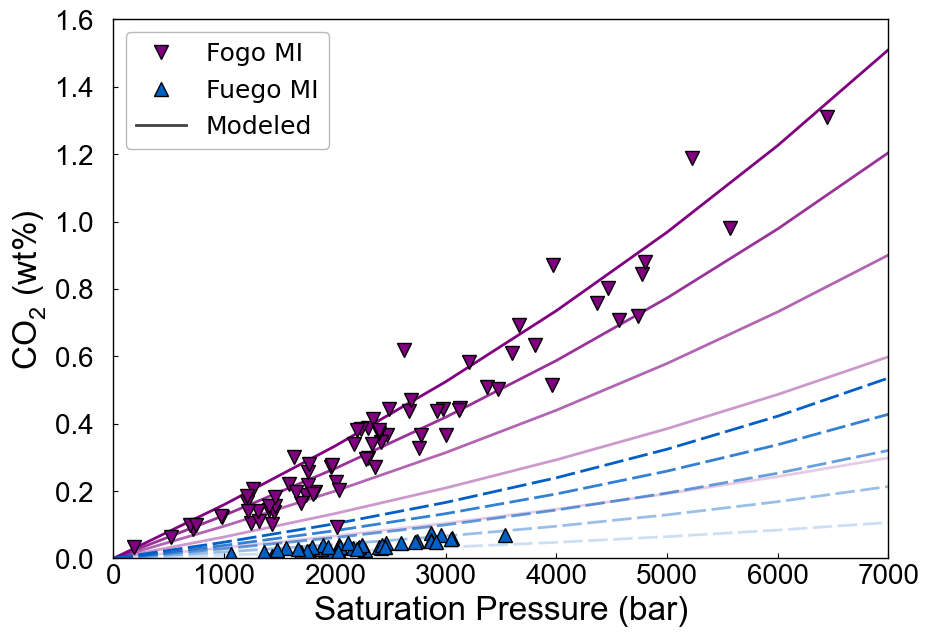

In [33]:
linestyles = ['-', (0, (7, 2)),]
markers = ['v','^',]
colors = ['#800080','#0160C6',]

# create the figure
fig, ax = plt.subplots(figsize=(10,7), dpi=100)

######### PLOT MI DATA POINTS ###########
for i, satPs in enumerate([satPs_fogo, satPs_fuego]):
        ax.plot(
                satPs['SaturationP_bars_VESIcal'],
                satPs['CO2'],
                markers[i],
                mfc=colors[i],
                mec='k',
                markersize=10,
                label=["Fogo MI", "Fuego MI"][i],
                zorder=2
                )

########## PLOT MODELED CURVES ###########
# Plot each X_fluid as a separate line for both volcanoes
for i, df in enumerate([fogo_curves, fuego_curves]):
        for x_fluid in [0, 0.2, 0.4, 0.6, 0.8]:
                line_label = "Modeled" if i == 1 and x_fluid == 0 else None
                data_subset = df[df['X_fluid_values'] == x_fluid]
                data_sorted = data_subset.sort_values('Pressures')  # Ensure sorted
                ax.plot(data_sorted['Pressures'], data_sorted['CO2s'], 
                        color=colors[i],
                        linestyle=linestyles[i],
                        lw=2,
                        alpha = 1 - x_fluid,
                        label=line_label,
                        zorder=1)

########## PLOT STYLING ###########
legend = ax.legend(fontsize=18)
legend.legend_handles[2].set_color("#424242")
legend.get_lines()[2].set_linestyle('-')
legend.get_frame().set_edgecolor('darkgray')


ax.set_xlabel(r'Saturation Pressure (bar)', fontsize=24, family='Arial')
ax.set_ylabel(r'CO$_2$ (wt%)', fontsize=24, family='Arial')
# Font settings
font = {'weight': 'normal',
        'size': 16,
        'family': 'Arial'
        }
ax.tick_params(axis='x', labelsize=20, direction='in')
ax.tick_params(axis='y', labelsize=20, direction='in')

ax.set_xlim(0,7000)
ax.set_ylim(0,1.6)

plt.xticks(fontname='Arial')
plt.yticks(fontname='Arial')

ax.yaxis.set_major_formatter('{x:<5.1f}')

fig.savefig('Figure3.png', dpi=600, bbox_inches="tight")   # save the figure to file

plt.show()
